# Agricultural Yield Prediction — All Models Comparison

Consolidated notebook combining:
- **Baseline linear models** (Linear Regression, Ridge, Lasso) with hyperparameter tuning
- **Tree/ensemble models** (Random Forest, XGBoost, Gradient Boosting) with hyperparameter tuning
- **Distance-based models** (KNN, SVR) with hyperparameter tuning

All models trained on the same preprocessed data for a fair, apples-to-apples comparison.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Tree / ensemble models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Distance-based models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

sns.set_theme(style="whitegrid", palette="muted")

## Load Data

In [3]:
df = pd.read_csv("../data/raw/Agri_yield_prediction.csv")
print(f"{df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df.head()

10,000 rows  ×  46 columns


,Temperature,Humidity,Rainfall,Soil_Type,pH,EC,OC,N,P,K,...,Planting_Date,Harvest_Date,Growth_Stage,Irrigation_Frequency,Fertilizer_Type,Pesticide_Usage,Yield,Region,Season,Year
0,21.236204,52.418449,218.999493,Sandy,6.937571,0.891838,0.267994,98.745262,5.273230,28.110766,...,2020-01-01,2020-04-01,Reproductive,2,Organic,Low,8.613835,South,Kharif,2000
1,38.521429,49.974726,55.353599,Clayey,4.655614,2.060172,0.127311,73.177475,144.197737,210.840395,...,2020-01-02,2020-04-02,Vegetative,7,Chemical,High,2.283444,North,Zaid,2003
2,31.959818,40.569235,103.991908,Loamy,6.949041,2.486504,1.495381,150.178286,82.620907,238.076459,...,2020-01-03,2020-04-03,Reproductive,25,Organic,High,8.707448,North,Zaid,2000
3,27.959755,66.436000,198.984191,Sandy,4.858674,2.117828,0.597238,33.275545,106.558078,144.667266,...,2020-01-04,2020-04-04,Vegetative,2,Mixed,Low,9.750230,North,Rabi,2014
4,14.680559,58.597450,144.626803,Loamy,7.341377,0.930743,1.767589,152.547715,137.326588,142.411240,...,2020-01-05,2020-04-05,Maturity,14,Mixed,Medium,2.518869,East,Rabi,2000


In [4]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

Missing values per column:
Series([], dtype: int64)

Duplicate rows: 0


,Temperature,Humidity,Rainfall,pH,EC,OC,N,P,K,Ca,...,Solar_Radiation,Wind_Speed,NDVI,EVI,LAI,Chlorophyll,GDD,Irrigation_Frequency,Yield,Year
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,24.824787,60.271793,150.015118,6.490537,1.299315,1.052179,105.189957,77.882509,128.936654,1021.092552,...,548.883988,9.978476,-0.001732,-0.003975,2.992829,30.053218,1593.572485,14.886900,5.469953,2011.984300
std,8.628904,17.357673,86.032127,1.157898,0.693123,0.547959,54.384247,41.760995,69.795901,562.529135,...,259.531126,5.787656,0.577548,0.576211,1.722940,11.541534,806.061301,8.362039,2.633444,7.199753
min,10.000349,30.009465,0.014437,4.500067,0.100251,0.100016,10.028726,5.018852,10.024220,50.057232,...,100.175526,0.000721,-0.999983,-0.999996,0.000052,10.000893,200.051656,1.000000,1.000537,2000.000000
25%,17.389866,45.236748,76.124373,5.487267,0.696678,0.584613,58.195799,41.460738,67.355874,528.872078,...,323.890172,4.937410,-0.504502,-0.504195,1.502946,19.902505,893.715244,8.000000,3.182187,2006.000000
50%,24.775859,60.353807,150.620428,6.475950,1.307264,1.051160,105.025338,78.813574,129.225613,1027.193414,...,551.442577,9.981912,-0.001227,-0.011656,2.986978,29.918376,1587.633472,15.000000,5.444636,2012.000000
75%,32.200190,75.388753,223.402156,7.498969,1.899912,1.530551,152.900276,113.865999,189.642263,1504.748199,...,775.738626,14.928717,0.495559,0.502059,4.485248,40.089844,2287.804118,22.000000,7.779091,2018.000000
max,39.991530,89.995490,299.970293,8.499889,2.499897,1.999885,199.976269,149.980744,249.998090,1999.953150,...,999.919726,19.997770,0.999854,0.999609,5.999257,49.999784,2999.016275,29.000000,9.999242,2024.000000


## EDA — Target & Key Features

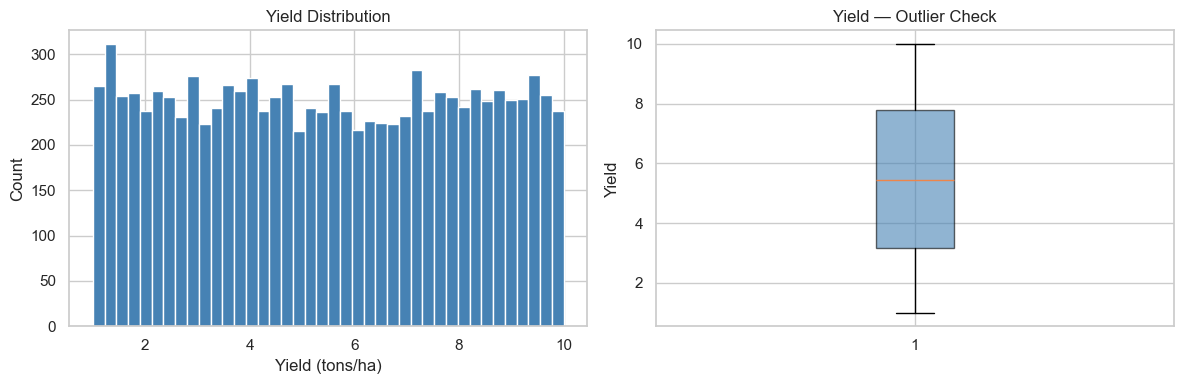

count    10000.000000
mean         5.469953
std          2.633444
min          1.000537
25%          3.182187
50%          5.444636
75%          7.779091
max          9.999242
Name: Yield, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Yield"], bins=40, color="steelblue", edgecolor="white")
axes[0].set(title="Yield Distribution", xlabel="Yield (tons/ha)", ylabel="Count")

axes[1].boxplot(df["Yield"], patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set(title="Yield — Outlier Check", ylabel="Yield")

plt.tight_layout()
plt.show()

print(df["Yield"].describe())

Top 15 features by |r| with Yield:
Cu                        0.0264
Bulk_Density              0.0196
Clay                      0.0193
Elevation                 0.0189
Chlorophyll               0.0182
NDVI                      0.0161
Mo                        0.0153
Humidity                  0.0115
S                         0.0113
GDD                       0.0110
P                         0.0101
Irrigation_Frequency      0.0099
Ca                        0.0088
K                         0.0087
Water_Holding_Capacity    0.0079
Name: Yield, dtype: float64


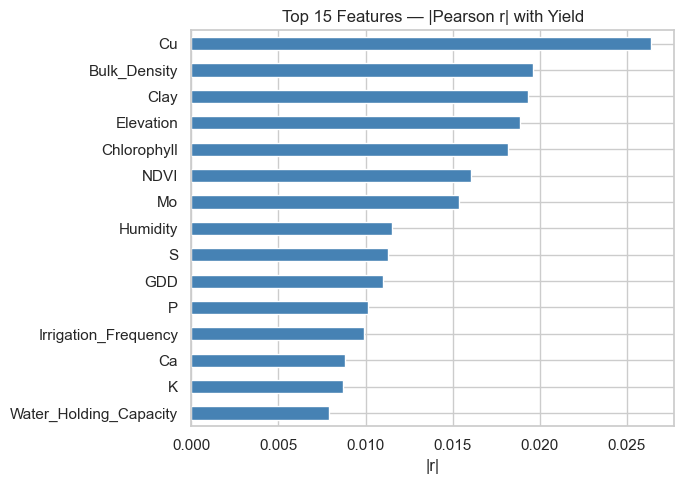

In [6]:
# Pearson correlations with Yield — shows weak linear relationships
num_corr = df.select_dtypes(include="number").corr()["Yield"].drop("Yield").abs().sort_values(ascending=False)
print("Top 15 features by |r| with Yield:")
print(num_corr.head(15).round(4))

fig, ax = plt.subplots(figsize=(7, 5))
num_corr.head(15).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set(title="Top 15 Features — |Pearson r| with Yield", xlabel="|r|")
plt.tight_layout()
plt.show()

## Feature Engineering

In [7]:
df["Planting_Date"] = pd.to_datetime(df["Planting_Date"], errors="coerce")
df["Harvest_Date"]  = pd.to_datetime(df["Harvest_Date"],  errors="coerce")

df["Crop_Duration"]       = (df["Harvest_Date"] - df["Planting_Date"]).dt.days
df["Planting_Month"]      = df["Planting_Date"].dt.month
df["Planting_DayOfYear"]  = df["Planting_Date"].dt.dayofyear
df["Harvest_Month"]       = df["Harvest_Date"].dt.month
df["Harvest_DayOfYear"]   = df["Harvest_Date"].dt.dayofyear

df.drop(columns=["Planting_Date", "Harvest_Date"], inplace=True)

print(f"Shape after feature engineering: {df.shape}")
df[["Crop_Duration", "Planting_Month", "Harvest_Month"]].describe()

Shape after feature engineering: (10000, 49)


,Crop_Duration,Planting_Month,Harvest_Month
count,10000.0,10000.000000,10000.000000
mean,91.0,6.471800,6.513400
std,0.0,3.455691,3.429314
min,91.0,1.000000,1.000000
25%,91.0,3.000000,4.000000
50%,91.0,6.000000,7.000000
75%,91.0,9.000000,9.000000
max,91.0,12.000000,12.000000


## Preprocessing & Train/Test Split

In [8]:
X = df.drop(columns=["Yield"])
y = df["Yield"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols     = X.select_dtypes(exclude="object").columns.tolist()

print(f"Numerical : {len(numeric_cols)} features")
print(f"Categorical: {len(categorical_cols)} features → {categorical_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape}   Test: {X_test.shape}")

Numerical : 41 features
Categorical: 7 features → ['Soil_Type', 'Crop_Type', 'Growth_Stage', 'Fertilizer_Type', 'Pesticide_Usage', 'Region', 'Season']

Train: (8000, 48)   Test: (2000, 48)


In [9]:
# Two preprocessors:
#   tree_preprocessor  — for tree/ensemble models (no scaling needed)
#   scaled_preprocessor — for linear and distance-based models (scaling required)

tree_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

scaled_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])

## Shared Utilities

In [10]:
def evaluate_search(name, search_obj, X_train, y_train, X_test, y_test):
    """Fit a RandomizedSearchCV object, evaluate on test set, and return a result dict."""
    search_obj.fit(X_train, y_train)
    best_model = search_obj.best_estimator_
    preds = best_model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    print(f"{name:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    print(f"  Best params: {search_obj.best_params_}\n")

    return {
        "Model":       name,
        "MAE":         round(mae,  4),
        "RMSE":        round(rmse, 4),
        "R²":          round(r2,   4),
        "Best Params": search_obj.best_params_,
        "Estimator":   best_model,
    }

all_results = []

## 1. Linear Models (Linear Regression, Ridge, Lasso)

Linear Regression has no hyperparameters to tune. Ridge and Lasso are tuned over their regularization strength `alpha`.
These models serve as baselines; weak linear correlations with Yield mean we expect low R².

In [11]:
# --- Linear Regression (no tuning) ---
lr_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_r2   = r2_score(y_test, lr_preds)

print(f"{'Linear Regression':30s}  RMSE={lr_rmse:.4f}  MAE={lr_mae:.4f}  R²={lr_r2:.4f}")
all_results.append({
    "Model":       "Linear Regression",
    "MAE":         round(lr_mae,  4),
    "RMSE":        round(lr_rmse, 4),
    "R²":          round(lr_r2,   4),
    "Best Params": "N/A",
    "Estimator":   lr_pipeline,
})

Linear Regression               RMSE=2.6379  MAE=2.2824  R²=-0.0120


In [12]:
# --- Ridge with hyperparameter tuning ---
ridge_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", Ridge()),
])
ridge_param_dist = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0],
}
ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=ridge_param_dist,
    n_iter=7,           # small grid — exhaustive is fine here
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("Ridge", ridge_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Ridge                           RMSE=2.6352  MAE=2.2811  R²=-0.0099
  Best params: {'model__alpha': 500.0}



In [13]:
# --- Lasso with hyperparameter tuning ---
lasso_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", Lasso(max_iter=10000)),
])
lasso_param_dist = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}
lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=lasso_param_dist,
    n_iter=7,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("Lasso", lasso_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Lasso                           RMSE=2.6272  MAE=2.2755  R²=-0.0038
  Best params: {'model__alpha': 1.0}



## 2. Tree / Ensemble Models (Random Forest, XGBoost, Gradient Boosting)

Tree-based models handle non-linear relationships well and don't require feature scaling.
GBR (sklearn's `GradientBoostingRegressor`) is added alongside the RF and XGBoost from the team's earlier notebook.

In [14]:
# --- Random Forest ---
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])
rf_param_dist = {
    "model__n_estimators":     [150, 250, 350],
    "model__max_depth":        [None, 10, 20, 30],
    "model__min_samples_split":[2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features":     ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("Random Forest", rf_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest                   RMSE=2.6307  MAE=2.2797  R²=-0.0065
  Best params: {'model__n_estimators': 250, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10}



In [15]:
# --- XGBoost ---
xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )),
])
xgb_param_dist = {
    "model__n_estimators":    [150, 250, 350],
    "model__max_depth":       [3, 5, 7, 9],
    "model__learning_rate":   [0.03, 0.05, 0.1],
    "model__subsample":       [0.8, 0.9, 1.0],
    "model__colsample_bytree":[0.8, 0.9, 1.0],
    "model__reg_alpha":       [0, 0.1, 1],
    "model__reg_lambda":      [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("XGBoost", xgb_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGBoost                         RMSE=2.6318  MAE=2.2806  R²=-0.0073
  Best params: {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}



In [16]:
# --- Gradient Boosting Regressor (NEW) ---
gbr_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingRegressor(random_state=42)),
])
gbr_param_dist = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [3, 5, 7],
    "model__learning_rate":    [0.03, 0.05, 0.1, 0.15],
    "model__subsample":        [0.7, 0.8, 0.9, 1.0],
    "model__min_samples_split":[2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features":     ["sqrt", "log2", None],
}
gbr_search = RandomizedSearchCV(
    gbr_pipeline,
    param_distributions=gbr_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("Gradient Boosting", gbr_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Gradient Boosting               RMSE=2.6301  MAE=2.2790  R²=-0.0060
  Best params: {'model__subsample': 0.9, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 3, 'model__learning_rate': 0.05}



## 3. Distance-Based Models (KNN, SVR)

Both models are sensitive to feature scale, so they use `scaled_preprocessor`.

> **Note on SVR:** SVR has O(n²)–O(n³) training complexity. For large datasets the hyperparameter
> search is run on a random subsample (10 000 rows) to keep runtime reasonable; the best estimator
> is then fitted on the full training set.

In [17]:
# --- KNN ---
knn_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", KNeighborsRegressor()),
])
knn_param_dist = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights":     ["uniform", "distance"],
    "model__p":           [1, 2],
}
knn_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=knn_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
all_results.append(evaluate_search("KNN", knn_search, X_train, y_train, X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
KNN                             RMSE=2.7297  MAE=2.3341  R²=-0.0837
  Best params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 15}



In [18]:
# --- SVR (NEW) ---
# Subsample for hyperparameter search to control runtime
SVR_SAMPLE = min(10_000, len(X_train))
rng = np.random.default_rng(42)
svr_idx = rng.choice(len(X_train), size=SVR_SAMPLE, replace=False)
X_train_svr = X_train.iloc[svr_idx]
y_train_svr = y_train.iloc[svr_idx]

svr_pipeline = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", SVR()),
])
svr_param_dist = {
    "model__C":       [0.1, 1.0, 10.0, 100.0],
    "model__epsilon": [0.01, 0.1, 0.5, 1.0],
    "model__kernel":  ["rbf", "linear"],
    "model__gamma":   ["scale", "auto"],
}
svr_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=svr_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

# Tune on subsample, refit best config on full training set
svr_search.fit(X_train_svr, y_train_svr)
best_svr_params = {k.replace("model__", ""): v for k, v in svr_search.best_params_.items()}
print(f"Best SVR params (from subsample): {svr_search.best_params_}")

final_svr = Pipeline([
    ("preprocessor", scaled_preprocessor),
    ("model", SVR(**best_svr_params)),
])
final_svr.fit(X_train, y_train)
svr_preds = final_svr.predict(X_test)

svr_mae  = mean_absolute_error(y_test, svr_preds)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_preds))
svr_r2   = r2_score(y_test, svr_preds)

print(f"{'SVR':30s}  RMSE={svr_rmse:.4f}  MAE={svr_mae:.4f}  R²={svr_r2:.4f}")
all_results.append({
    "Model":       "SVR",
    "MAE":         round(svr_mae,  4),
    "RMSE":        round(svr_rmse, 4),
    "R²":          round(svr_r2,   4),
    "Best Params": svr_search.best_params_,
    "Estimator":   final_svr,
})

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best SVR params (from subsample): {'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__epsilon': 1.0, 'model__C': 0.1}
SVR                             RMSE=2.6330  MAE=2.2810  R²=-0.0082


## Results — All Models

In [19]:
results_df = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "Estimator"} for r in all_results])
    .sort_values("RMSE")
    .reset_index(drop=True)
)
results_df

,Model,MAE,RMSE,R²,Best Params
0,Lasso,2.2755,2.6272,-0.0038,{'model__alpha': 1.0}
1,Gradient Boosting,2.2790,2.6301,-0.0060,"{'model__subsample': 0.9, 'model__n_estimators..."
2,Random Forest,2.2797,2.6307,-0.0065,"{'model__n_estimators': 250, 'model__min_sampl..."
3,XGBoost,2.2806,2.6318,-0.0073,"{'model__subsample': 0.8, 'model__reg_lambda':..."
4,SVR,2.2810,2.6330,-0.0082,"{'model__kernel': 'rbf', 'model__gamma': 'scal..."
5,Ridge,2.2811,2.6352,-0.0099,{'model__alpha': 500.0}
6,Linear Regression,2.2824,2.6379,-0.0120,N/A
7,KNN,2.3341,2.7297,-0.0837,"{'model__weights': 'distance', 'model__p': 1, ..."


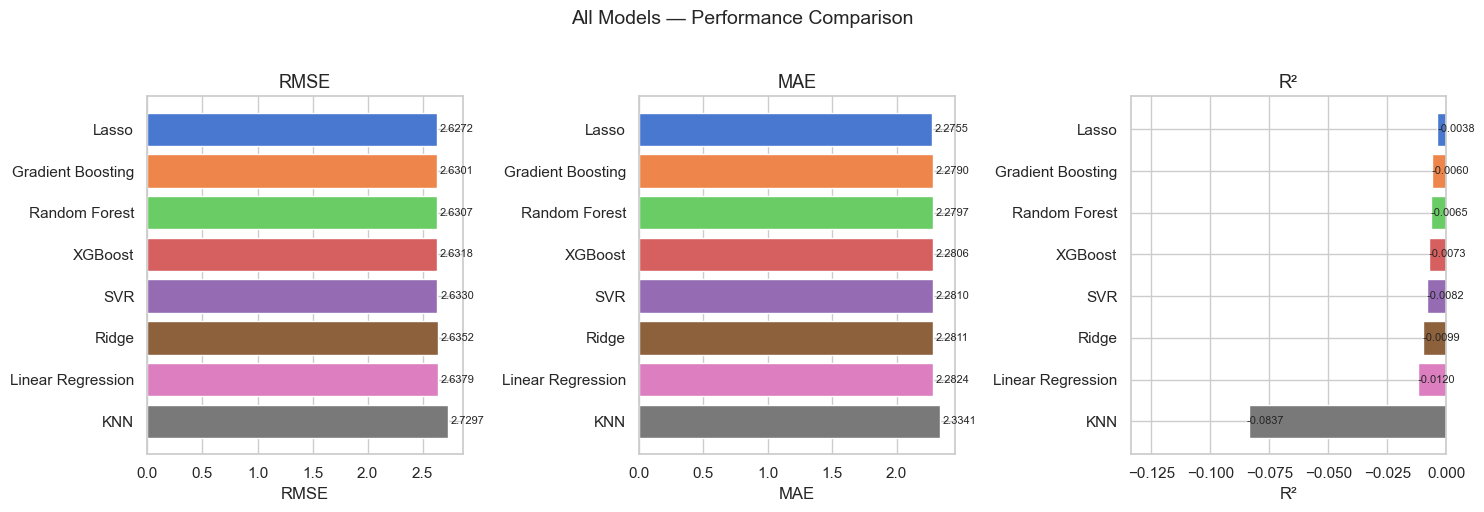

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = sns.color_palette("muted", len(results_df))

for ax, metric, color_list in zip(axes, ["RMSE", "MAE", "R²"], [palette, palette, palette]):
    bars = ax.barh(results_df["Model"], results_df[metric], color=color_list, edgecolor="white")
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel(metric)
    if metric == "R²":
        ax.set_xlim(left=min(0, results_df[metric].min() - 0.05))
    ax.invert_yaxis()
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width() + bar.get_width() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)

plt.suptitle("All Models — Performance Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance — Tree-Based Models

Shows which features drive yield predictions for RF, XGBoost, and GBR.

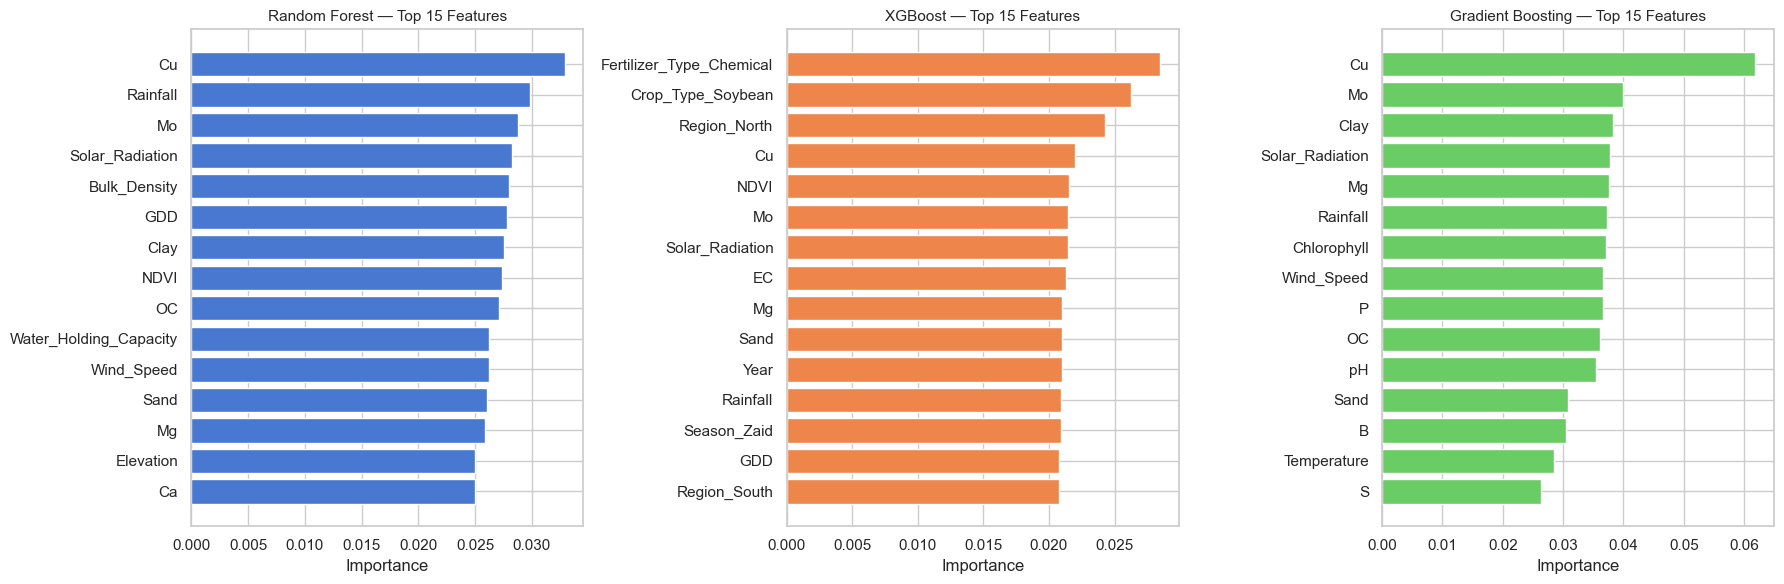

In [21]:
def get_feature_names(preprocessor):
    """Extract ordered feature names from a ColumnTransformer."""
    names = []
    for _, transformer, cols in preprocessor.transformers_:
        if transformer == "drop" or transformer == "passthrough":
            names.extend(cols)
            continue
        if hasattr(transformer, "named_steps") and "onehot" in transformer.named_steps:
            ohe = transformer.named_steps["onehot"]
            names.extend(ohe.get_feature_names_out(cols))
        else:
            names.extend(cols)
    return names

tree_model_names = ["Random Forest", "XGBoost", "Gradient Boosting"]
fig, axes = plt.subplots(1, len(tree_model_names), figsize=(18, 6))

for ax, model_name in zip(axes, tree_model_names):
    row = next(r for r in all_results if r["Model"] == model_name)
    pipeline   = row["Estimator"]
    preproc    = pipeline.named_steps["preprocessor"]
    regressor  = pipeline.named_steps["model"]
    feat_names = get_feature_names(preproc)
    importances = regressor.feature_importances_

    top_idx = np.argsort(importances)[-15:]
    ax.barh([feat_names[i] for i in top_idx], importances[top_idx],
            color=sns.color_palette("muted")[tree_model_names.index(model_name)],
            edgecolor="white")
    ax.set_title(f"{model_name} — Top 15 Features", fontsize=11)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Summary

```
Best model by RMSE:
```

In [22]:
best = results_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"RMSE       : {best['RMSE']}")
print(f"MAE        : {best['MAE']}")
print(f"R²         : {best['R²']}")
print(f"Best params: {best['Best Params']}")

print("\n--- Full leaderboard ---")
print(results_df[["Model", "RMSE", "MAE", "R²"]].to_string(index=False))

Best model : Lasso
RMSE       : 2.6272
MAE        : 2.2755
R²         : -0.0038
Best params: {'model__alpha': 1.0}

--- Full leaderboard ---
            Model   RMSE    MAE      R²
            Lasso 2.6272 2.2755 -0.0038
Gradient Boosting 2.6301 2.2790 -0.0060
    Random Forest 2.6307 2.2797 -0.0065
          XGBoost 2.6318 2.2806 -0.0073
              SVR 2.6330 2.2810 -0.0082
            Ridge 2.6352 2.2811 -0.0099
Linear Regression 2.6379 2.2824 -0.0120
              KNN 2.7297 2.3341 -0.0837
